Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='str')


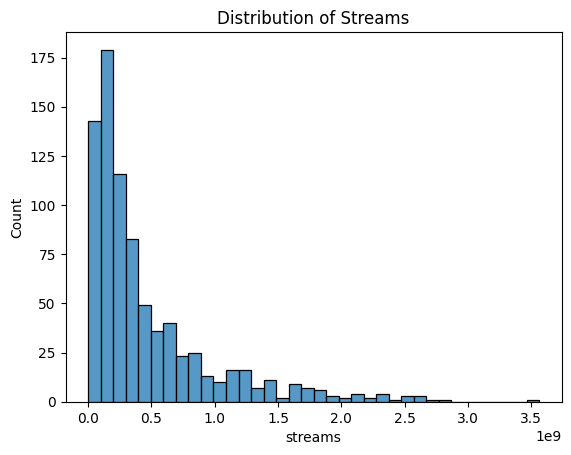

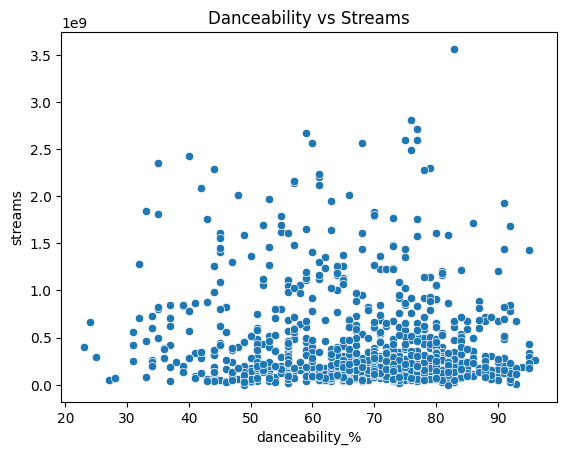

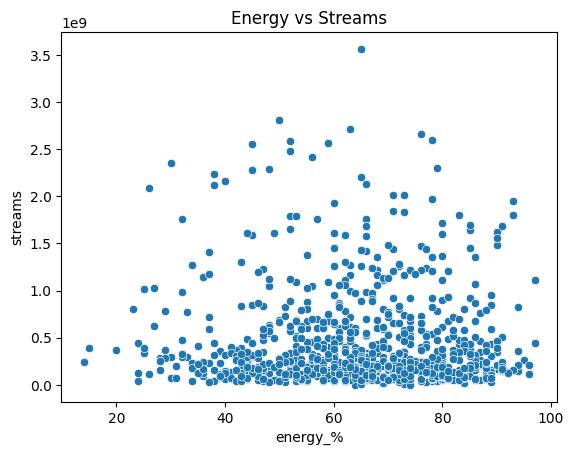

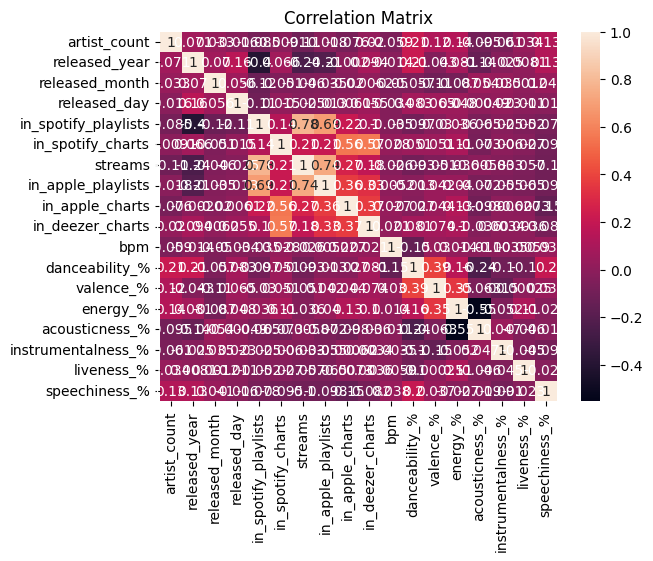

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load with correct encoding
df = pd.read_csv("../data/raw/spotify-2023.csv", encoding="latin1")

# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

# Cleaning
df = df.drop_duplicates()
df = df.dropna()

# FIX: find actual column names dynamically
dance_col = next((c for c in df.columns if "dance" in c), None)
energy_col = next((c for c in df.columns if "energy" in c), None)
streams_col = next((c for c in df.columns if "stream" in c), None)

# Convert to numeric
for col in [dance_col, energy_col, streams_col]:
    if col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop NaN only for existing columns
cols_to_use = [c for c in [dance_col, energy_col, streams_col] if c]
df = df.dropna(subset=cols_to_use)

# Visualization 1
sns.histplot(df[streams_col])
plt.title("Distribution of Streams")
plt.show()

# Visualization 2
if dance_col and streams_col:
    sns.scatterplot(x=dance_col, y=streams_col, data=df)
    plt.title("Danceability vs Streams")
    plt.show()

# Visualization 3
if energy_col and streams_col:
    sns.scatterplot(x=energy_col, y=streams_col, data=df)
    plt.title("Energy vs Streams")
    plt.show()

# Visualization 4
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Save cleaned data
df.to_csv("../data/cleaned.csv", index=False)